In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load dataset
sales = pd.read_csv('data.csv', encoding='latin1')

# Show first 5 rows
sales.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
# Dataset shape
print('Rows and Columns:', sales.shape)

# Column names
print('\nColumns:')
print(sales.columns)

# Dataset information
print('\nDataset Info:')
sales.info()

Rows and Columns: (541909, 8)

Columns:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
# Missing values
sales.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
# Remove missing values
sales.dropna(inplace=True)

# Remove negative quantity
sales = sales[sales['Quantity'] > 0]

# Remove negative price
sales = sales[sales['UnitPrice'] > 0]

# Convert date column
sales['InvoiceDate'] = pd.to_datetime(sales['InvoiceDate'])

print('Cleaned Data Shape:', sales.shape)

Cleaned Data Shape: (397884, 8)


In [ ]:
# Create revenue column
sales['Revenue'] = sales['Quantity'] * sales['UnitPrice']

sales.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [ ]:
# Total revenue
print('Total Revenue:', sales['Revenue'].sum())

Total Revenue: 8911407.904


In [ ]:
# Top products
top_products = sales.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

print(top_products)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: Revenue, dtype: float64


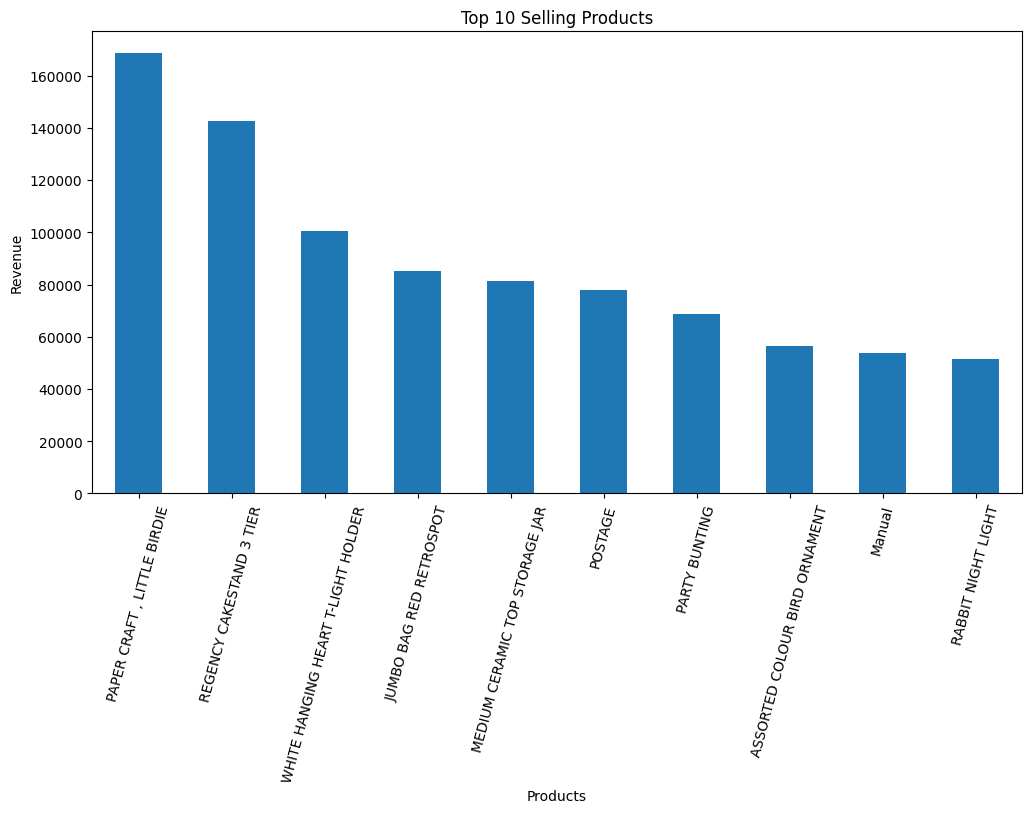

In [ ]:
plt.figure(figsize=(12,6))
top_products.plot(kind='bar')

plt.title('Top 10 Selling Products')
plt.xlabel('Products')
plt.ylabel('Revenue')
plt.xticks(rotation=75)

plt.show()

In [ ]:
country_sales = sales.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

print(country_sales)

Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: Revenue, dtype: float64


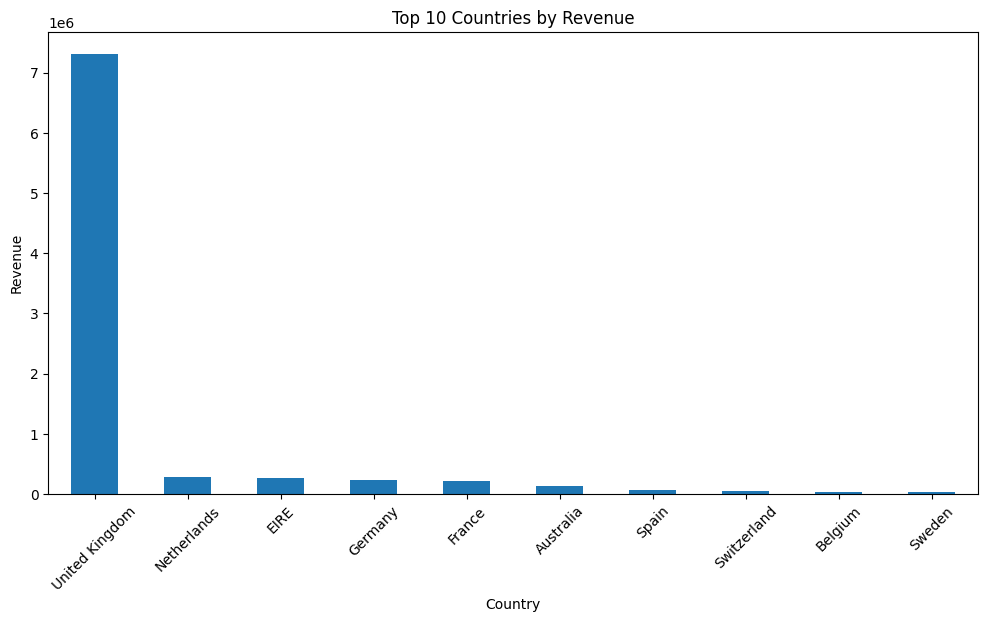

In [ ]:
plt.figure(figsize=(12,6))
country_sales.plot(kind='bar')

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.show()

In [ ]:
# Create month column
sales['Month'] = sales['InvoiceDate'].dt.to_period('M')

monthly_sales = sales.groupby('Month')['Revenue'].sum()

print(monthly_sales)

Month
2010-12     572713.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518192.790
Freq: M, Name: Revenue, dtype: float64


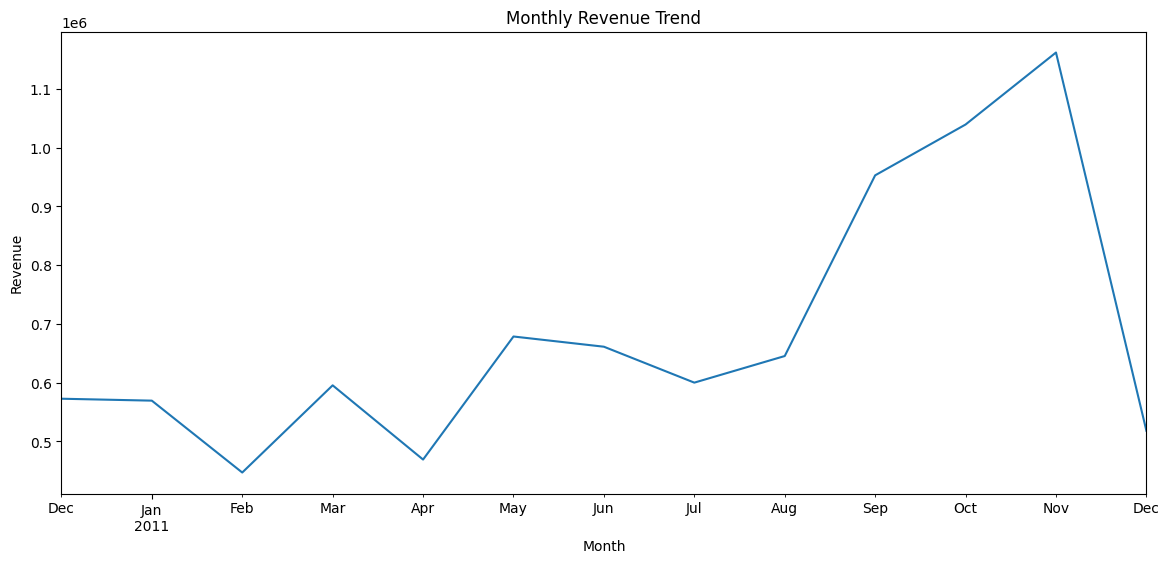

In [ ]:
plt.figure(figsize=(14,6))
monthly_sales.plot()

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()

In [ ]:
customer_sales = sales.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)

print(customer_sales)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: Revenue, dtype: float64


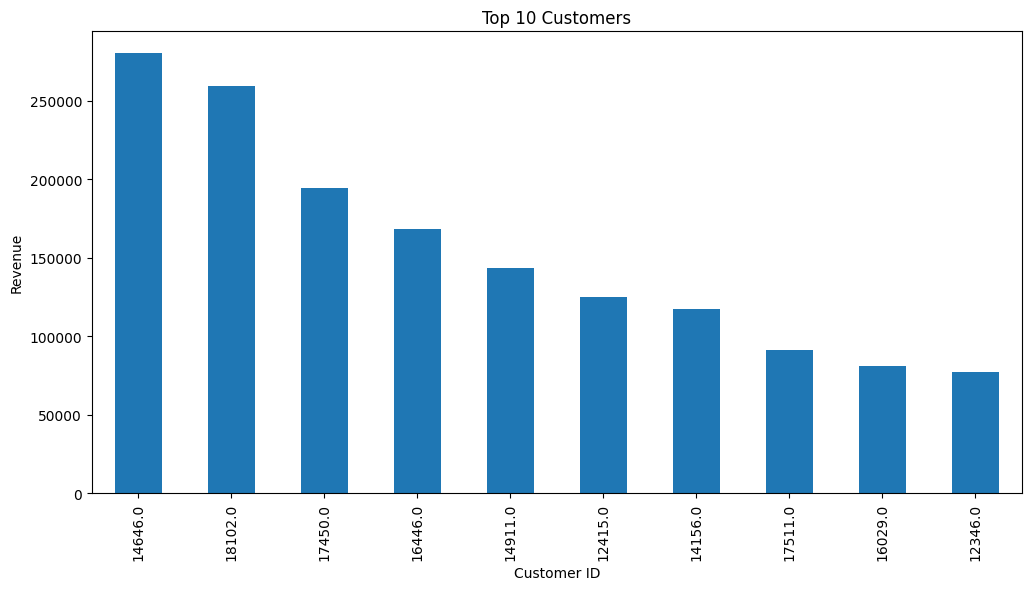

In [ ]:
plt.figure(figsize=(12,6))
customer_sales.plot(kind='bar')

plt.title('Top 10 Customers')
plt.xlabel('Customer ID')
plt.ylabel('Revenue')

plt.show()

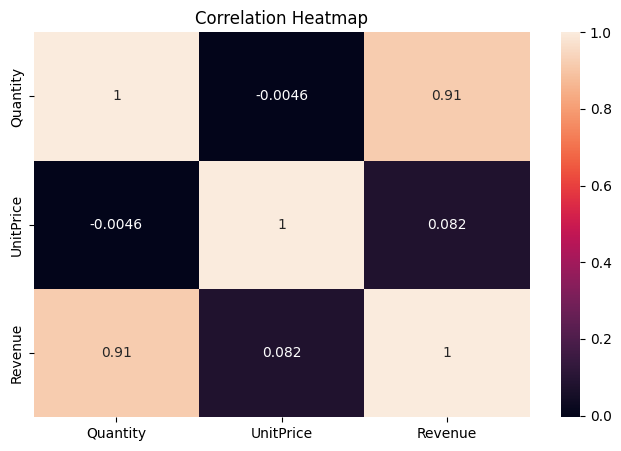

In [ ]:
numeric_data = sales[['Quantity', 'UnitPrice', 'Revenue']]

plt.figure(figsize=(8,5))
sns.heatmap(numeric_data.corr(), annot=True)

plt.title('Correlation Heatmap')

plt.show()